In [1]:
from autoenkoop import *
import torch
from torch.utils.data import DataLoader
import numpy as np
from numpy.linalg import svd, eig
import pandas as pd
import os
import pydmd
from pydmd.plotter import plot_summary
from tqdm import tqdm
from matplotlib.colors import Normalize
import matplotlib.pyplot as plt

DEVICE = "cuda"

In [2]:
data_path = os.path.join("..", "data", "T1492_x1151_y1_z127_c2.npz")
center_dataset = True
train_test_split = 0.7
train_data, test_data, temp_mean = load_and_prepare_data(data_path, center_dataset, train_test_split)

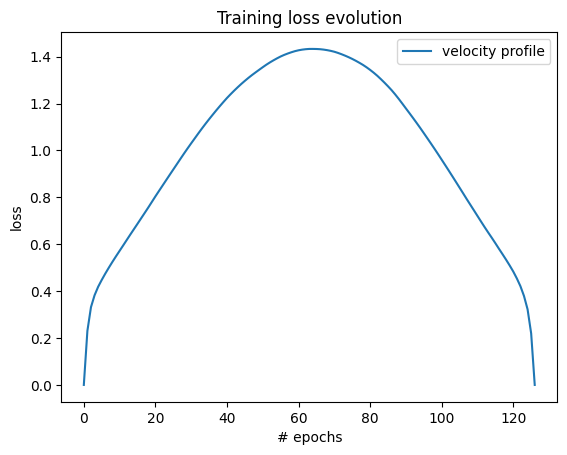

In [3]:
plot_evolution(temp_mean[800,:,0], "velocity profile")
plt.yscale("linear")

In [4]:
X = train_data.reshape(train_data.shape[0], -1).T
dmd = pydmd.DMD(svd_rank=2, exact=False)
dmd.fit(X)

c:\Users\paulf\miniconda3\Lib\site-packages\pydmd\snapshots.py:73: UserWarning: Input data condition number 3214297595235223.5. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(


In [32]:
U, S, Vh = np.linalg.svd(X.T, full_matrices=False)

In [42]:
Ur = U[:, :3]

In [43]:
Sr = S[:3]

In [45]:
Vhr = Vh[:, :3]

In [46]:
Xr = Ur @ np.diag(Sr)

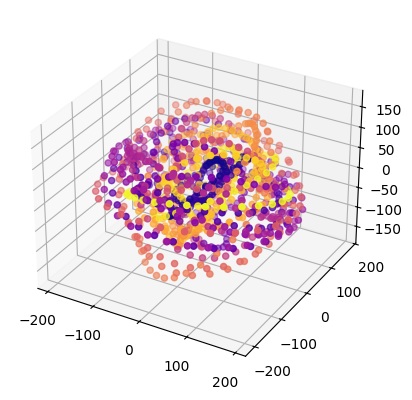

In [50]:
import matplotlib

cmap = matplotlib.colormaps['plasma']

# Take colors at regular intervals spanning the colormap.
colors = cmap(np.linspace(0, 1, 1045))

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(Xr[:, 0], Xr[:, 1], Xr[:, 2], c=colors)
#plt.ylim(0, 0.25)
#plt.xlim(0, 0.75)

In [18]:
eigvalues = dmd.eigs

In [19]:
dmd.modes.shape

(292354, 128)

In [20]:
eigenergies = np.mean(dmd.modes, axis=0)

In [21]:
eigenergies.shape

(128,)

c:\Users\paulf\miniconda3\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\paulf\miniconda3\Lib\site-packages\matplotlib\axes\_axes.py:4730: ComplexWarning: Casting complex values to real discards the imaginary part
  c = np.asanyarray(c, dtype=float)


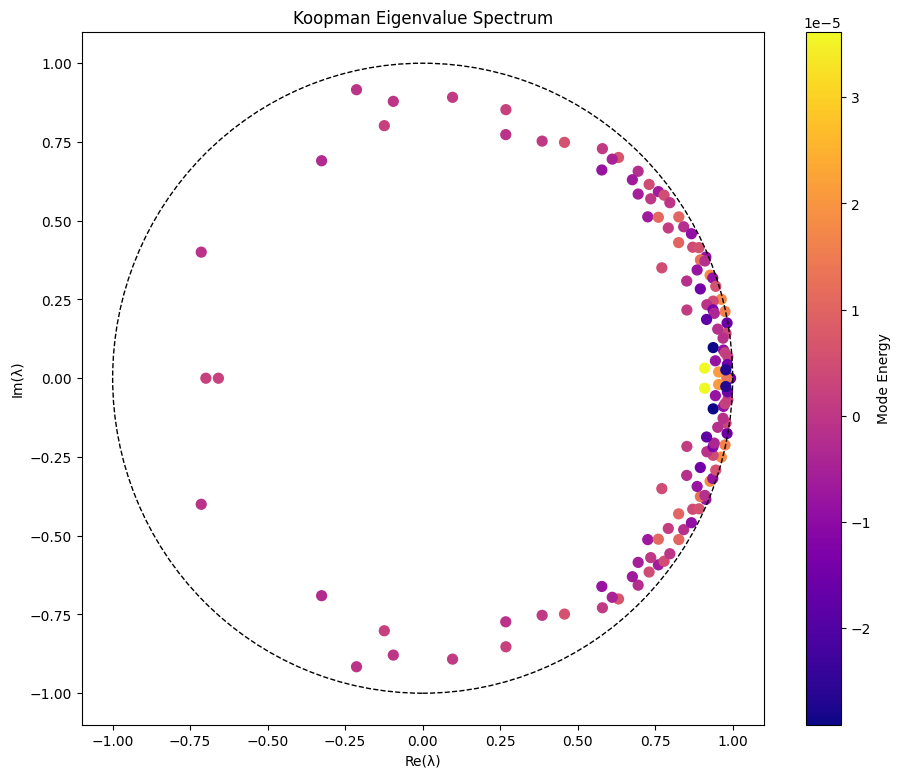

In [22]:
plot_eigenvalue_spectrum(eigvalues, eigenergies)

In [4]:
full_data = np.concatenate((train_data, test_data), axis=0)
PREDICTION_WINDOW = 100
window_offset_data = full_data[:-PREDICTION_WINDOW]

In [5]:
X_full = torch.tensor(full_data.reshape(full_data.shape[0], -1))
X_offset = torch.tensor(window_offset_data.reshape(window_offset_data.shape[0], -1), dtype=torch.complex128)

In [6]:
#PREDICTION_WINDOW
m = PREDICTION_WINDOW
steps = torch.arange(0, m + 1, device="cpu").reshape(-1, 1)
eigvalue_powers = torch.pow(torch.tensor(dmd.eigs), steps)

In [8]:
eigvalue_powers.shape

torch.Size([101, 128])

In [9]:
V = torch.tensor(dmd.modes)
V_inv = torch.linalg.pinv(V)

In [12]:
V_inv.shape

torch.Size([128, 292354])

In [ ]:
#np.zeros((X_offset.shape[0], PREDICTION_WINDOW+1))
mse_window = []
for i, x_t in tqdm(enumerate(X_offset), total=X_offset.shape[0]):
    z_t = V_inv @ x_t
    z_traj = eigvalue_powers * z_t
    x_pred = (V @ z_traj.T).real
    
    x_true = X_full[i:i+PREDICTION_WINDOW+1].T.real
    
    error = np.mean(((x_pred - x_true)**2).numpy(), axis=0)
    mse_window.append(error)
    break

  0%|          | 0/1393 [00:00<?, ?it/s]

torch.Size([292354])
torch.Size([128])
torch.Size([101, 128])
torch.Size([292354, 101])


  0%|          | 0/1393 [00:00<?, ?it/s]


In [23]:
mse_window_array = [np.array(mse_window)]

In [24]:
np.save("exactdmd_prediction100", mse_window_array[0])

In [25]:
mse_window_array.append(np.load("dmd_prediction100.npy"))

In [26]:
train_test_cutoff = int(full_data.shape[0]*0.7)

In [27]:
train_mean_mse = []
test_mean_mse = []

for _, windowed_mse in enumerate(mse_window_array):
    #if run_name_list[i] != "L128_e300_lamlin10_train":
    train_mean_mse.append(np.mean(windowed_mse[:train_test_cutoff], 0))
    test_mean_mse.append(np.mean(windowed_mse[train_test_cutoff:], 0))

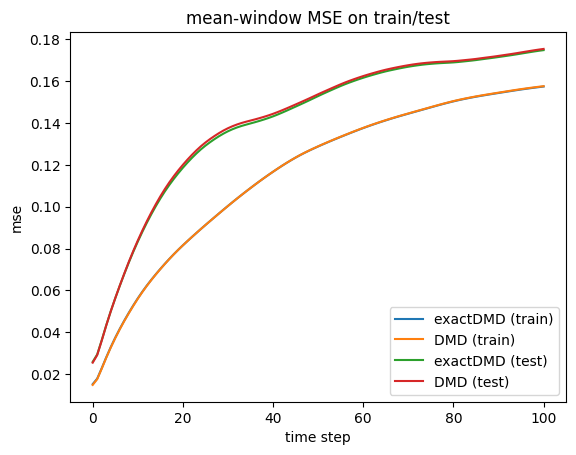

In [29]:
plot_evolution(train_mean_mse + test_mean_mse, ["exactDMD (train)", "DMD (train)", "exactDMD (test)", "DMD (test)"], "mean-window MSE on train/test", "time step", "mse")
plt.yscale("linear")